In [1]:
# 1. Read and analyze the thinking in Paper [1].
# 2. Call RDKit functions to generate molecule descriptors for the data set.
# 3. Implement machine learning models to fit and predict LogP with the selected features.

import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns   
from sklearn.linear_model import RidgeCV 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
import joblib
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from sklearn import linear_model
from keras.layers import Layer
from keras import backend as K
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.losses import binary_crossentropy



%matplotlib inline
print("j")


2025-10-09 13:48:56.047438: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


j


# Goal: create an algorithm f(x) that takes the smiles data as input and returns the logP as the output

# Importing synthetic dataset 
### synthetic dataset created using XLogP and does not contain experimental validation

In [2]:
df = pd.read_csv('logP_dataset.csv', names=['smiles', 'logP'])
print(df.shape)  
print(df.head())

(14610, 2)
                                        smiles  logP
0                        C[C@H]([C@@H](C)Cl)Cl   2.3
1                                    C(C=CBr)N   0.3
2                                    CCC(CO)Br   1.3
3  [13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O   2.0
4                                      CCCOCCP   0.6


##### Mol objects contain the atoms, bonds, connectivity and coordinates of a molecule. It adds important 3D information, such as the distance between atoms, that may be useful to our model. We can use Mol objects to craft features of the chemical to provide as inputs to our model

In [3]:
#Method transforms smiles strings to mol rdkit object
df['mol'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x)) 

df.head()

,smiles,logP,mol
0,C[C@H]([C@@H](C)Cl)Cl,2.3,<rdkit.Chem.rdchem.Mol object at 0x14d273cde040>
1,C(C=CBr)N,0.3,<rdkit.Chem.rdchem.Mol object at 0x14d273cde120>
2,CCC(CO)Br,1.3,<rdkit.Chem.rdchem.Mol object at 0x14d273cde190>
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0,<rdkit.Chem.rdchem.Mol object at 0x14d273cde200>
4,CCCOCCP,0.6,<rdkit.Chem.rdchem.Mol object at 0x14d273cde270>


# Plotting chemical structures

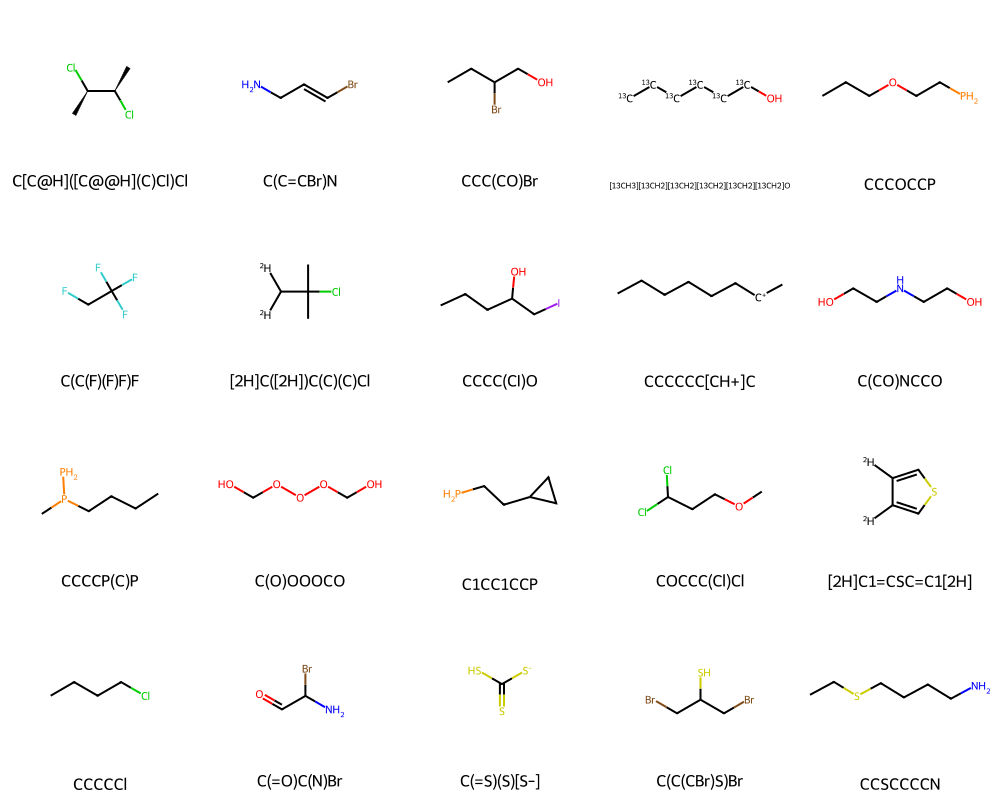

In [4]:
number_to_print = 20
mols = df['mol'][:number_to_print]

#MolsToGridImage allows to show several molecules in a grid
Draw.MolsToGridImage(mols, molsPerRow=5, useSVG=True, legends=list(df['smiles'][:number_to_print].values))

# Viewing molecules in 3D

In [5]:
# pip install ipywidgets==7.6. 0
# pip install py3Dmol

In [6]:
!pip install py3Dmol

In [7]:
import py3Dmol  
from ipywidgets import interact,fixed,IntSlider
import ipywidgets

def show3D_molecule(idx, style):
    """
    Show molecule in 3D
    """
    mblock = Chem.MolToMolBlock(df['mol'].iloc[idx])
    viewer = py3Dmol.view(width=500, height=500)
    viewer.addModel(mblock, 'mol')
    viewer.setStyle({style:{}})
    viewer.rotate(45, "y", animationDuration=1)
   
    viewer.zoomTo()
    
    print(f"SMILES notation: {df['smiles'].iloc[idx]}\nRotate me!");
    
    return viewer.show()
  
interact(show3D_molecule, 
         idx=ipywidgets.IntSlider(min=0,max=len(df["mol"])-1, 
                                  step=1, value=3064, 
                                  description="Molecule"),
         style=ipywidgets.Dropdown(options=['line', 'stick', 'sphere'],
                                   value='stick',
                                   description='Style:'));

ModuleNotFoundError: No module named 'ipywidgets'

# Creating features for the model
#### These features might be important for predicting logP. Such as: total number of atoms, number of Cl atoms etc

In [8]:
# AddHs function adds H atoms to a MOL (as Hs in SMILES are usualy ignored)
df['mol'] = df['mol'].apply(lambda x: Chem.AddHs(x))

In [9]:
# GetNumAtoms() method returns a general nubmer of all atoms in a molecule
df['num_of_atoms'] = df['mol'].apply(lambda x: x.GetNumAtoms())

# GetNumHeavyAtoms() method returns a nubmer of all atoms in a molecule with molecular weight > 1
df['num_of_heavy_atoms'] = df['mol'].apply(lambda x: x.GetNumHeavyAtoms())

#Searching for patterns and use it for a list of most common atoms only
def number_of_atoms(atom_list, df):
    for i in atom_list:
        df['num_of_{}_atoms'.format(i)] = df['mol'].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmiles(i))))

number_of_atoms(['C', 'O', 'N', 'Cl', 'P', 'Br', 'F'], df)

df['tpsa'] = df['mol'].apply(lambda x: Descriptors.TPSA(x)) #https://en.wikipedia.org/wiki/Polar_surface_area
df['mol_w'] = df['mol'].apply(lambda x: Descriptors.ExactMolWt(x)) # https://en.wikipedia.org/wiki/Molecular_mass
df['num_valence_electrons'] = df['mol'].apply(lambda x: Descriptors.NumValenceElectrons(x)) # https://en.wikipedia.org/wiki/Valence_electron
df['num_heteroatoms'] = df['mol'].apply(lambda x: Descriptors.NumHeteroatoms(x))

df.head()

,smiles,logP,mol,num_of_atoms,num_of_heavy_atoms,num_of_C_atoms,num_of_O_atoms,num_of_N_atoms,num_of_Cl_atoms,num_of_P_atoms,num_of_Br_atoms,num_of_F_atoms,tpsa,mol_w,num_valence_electrons,num_heteroatoms
0,C[C@H]([C@@H](C)Cl)Cl,2.3,<rdkit.Chem.rdchem.Mol object at 0x14d272b94b30>,14,6,4,0,0,2,0,0,0,0.00,126.000306,38,2
1,C(C=CBr)N,0.3,<rdkit.Chem.rdchem.Mol object at 0x14d272b94c80>,11,5,3,0,1,0,0,1,0,26.02,134.968361,30,2
2,CCC(CO)Br,1.3,<rdkit.Chem.rdchem.Mol object at 0x14d272b94ac0>,15,6,4,1,0,0,0,1,0,20.23,151.983677,38,2
3,[13CH3][13CH2][13CH2][13CH2][13CH2][13CH2]O,2.0,<rdkit.Chem.rdchem.Mol object at 0x14d272b94a50>,21,7,6,1,0,0,0,0,0,20.23,108.124594,44,1
4,CCCOCCP,0.6,<rdkit.Chem.rdchem.Mol object at 0x14d272b949e0>,20,7,5,1,0,0,1,0,0,9.23,120.070402,44,2


In [10]:
import requests

url = 'https://github.com/samoturk/mol2vec_notebooks/raw/master/Notebooks/model_300dim.pkl'
file_to_download = requests.get(url, allow_redirects=True)

open('model_300dim.pkl', 'wb').write(file_to_download.content)

26567327

In [9]:
pip install git+https://github.com/samoturk/mol2vec


  Cloning https://github.com/samoturk/mol2vec to /tmp/pip-req-build-yopig0m6
  Running command git clone --filter=blob:none --quiet https://github.com/samoturk/mol2vec /tmp/pip-req-build-yopig0m6
  Resolved https://github.com/samoturk/mol2vec to commit 850d944d5f48a58e26ed0264332b5741f72555aa
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [1]:
#!pip install scipy==1.9.3
!pip install numpy==1.24.4
!pip install --force-reinstall --no-cache-dir gensim

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 23.3 MB 13.4 MB/s eta 0:00:01
  Installing build dependencies ... error
  ERROR: Command errored out with exit status 1:
   command: /apps/cent7/anaconda/2024.02/bin/python /home/dnehra/.local/lib/python3.11/site-packages/pip install --ignore-installed --no-user --prefix /tmp/pip-build-env-t4gfpsl8/overlay --no-warn-script-location --no-binary :none: --only-binary :none: -i https://pypi.org/simple -- 'Cython>=0.29.32,<3.0.0' 'numpy==1.18.5; python_version=='"'"'3.8'"'"' and platform_machine not in '"'"'arm64|aarch64'"'"'' 'oldest-supported-numpy; python_version>'"'"'3.8'"'"' or platform_machine in '"'"'arm64|aarch64'"'"'' setuptools wheel
       cwd: None
  Complete output (1350 lines):
  Ignoring numpy: markers 'python_version == "3.8" and platform_machine not in "arm64|aarch64"' don't match 

In [11]:
from mol2vec.features import mol2alt_sentence, mol2sentence, MolSentence, DfVec, sentences2vec

In [12]:
#Loading pre-trained model via word2vec
from gensim.models import word2vec  # https://radimrehurek.com/gensim/index.html#install
from gensim.models import KeyedVectors
import numpy as np

def sentences2vec(sentences, model: KeyedVectors, unseen=None):
    keys = set(model.key_to_index.keys())
    vec = []
    for sentence in sentences:
        this_vec = []
        for word in sentence:  # <- FIXED HERE
            if word in keys:
                this_vec.append(model[word])
            elif unseen:
                this_vec.append(model[unseen])
        if this_vec:
            vec.append(np.sum(this_vec, axis=0))
        else:
            vec.append(np.zeros(model.vector_size))
    return vec


w2vec_model = word2vec.Word2Vec.load('model_300dim.pkl') # Download from https://github.com/samoturk/mol2vec_notebooks/blob/master/Notebooks/model_300dim.pkl

In [14]:
!pip uninstall gensim -y
!pip install gensim==3.8.3


Found existing installation: gensim 4.3.0
Uninstalling gensim-4.3.0:
ERROR: Exception:
Traceback (most recent call last):
  File "/apps/cent7/anaconda/2024.02/lib/python3.11/shutil.py", line 825, in move
    os.rename(src, real_dst)
OSError: [Errno 18] Invalid cross-device link: '/apps/cent7/anaconda/2024.02/lib/python3.11/site-packages/gensim-4.3.0.dist-info/' -> '/tmp/pip-uninstall-wnz5cyfl'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/dnehra/.local/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 228, in _main
    status = self.run(options, args)
             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dnehra/.local/lib/python3.11/site-packages/pip/_internal/commands/uninstall.py", line 89, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File "/home/dnehra/.local/lib/python3.11/site-packages/pip/_internal/req/req_install.py", line 686, in uninstall
    unin

In [15]:
!pip install gensim==3.8.3 --only-binary :all:


Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement gensim==3.8.3 (from versions: 0.8.8, 0.8.9, 0.9.0, 0.9.1, 0.10.0, 0.10.1)
ERROR: No matching distribution found for gensim==3.8.3


# Mol2Vec sentences

In [13]:
#Constructing sentences
df['sentence'] = df.apply(lambda x: MolSentence(mol2alt_sentence(x['mol'], 1)), axis=1)

#Extracting embeddings to a numpy.array
#unseen='UNK' in sentence2vec() so that model is taught how to handle unknown substructures
#df['mol2vec'] = [DfVec(x) for x in sentences2vec(df['sentence'], w2vec_model, unseen='UNK')]
df['mol2vec'] = [DfVec(x) for x in sentences2vec(df['sentence'], w2vec_model.wv, unseen='UNK')]


y = df['logP'].values
X = np.array([x.vec for x in df['mol2vec']])

[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerator
[13:50:15] DEPRECATION WARNING: please use MorganGenerat

# Combine features

In [14]:
X = pd.concat((pd.DataFrame(X), df.drop(["mol2vec", "sentence", "smiles", "mol", "logP"], axis=1)), axis=1)
print(X.head())

          0         1         2         3         4         5         6  \
0 -3.033099  3.074234 -5.136523  1.410768 -0.986690 -4.574900  5.233370   
1 -3.434874  1.474857 -4.590566  0.223204 -1.264612 -3.700434  5.138892   
2 -3.825828  2.155785 -6.192422 -0.167776 -0.660551 -5.452963  5.637180   
3 -4.575047  4.880448 -7.321297  1.438820 -1.936285 -6.090375  9.000039   
4 -4.621973  5.286204 -6.300099  1.157919 -1.416643 -5.956395  9.231432   

          7         8          9  ...  num_of_O_atoms  num_of_N_atoms  \
0  2.601740 -3.267953 -11.044377  ...               0               0   
1 -0.329877 -3.797274  -9.030344  ...               0               1   
2  0.801618 -4.901577 -12.064703  ...               1               0   
3 -0.387455 -6.985455 -17.531813  ...               1               0   
4 -1.259097 -6.625318 -16.902351  ...               1               0   

   num_of_Cl_atoms  num_of_P_atoms  num_of_Br_atoms  num_of_F_atoms   tpsa  \
0                2              

# Splitting synthetic dataset into Train/Validation/Test Splits


In [15]:
X_train, X_remain, y_train, y_remain = train_test_split(X, y, test_size=.2, random_state=816)
X_val, X_test, y_val, y_test = train_test_split(X_remain, y_remain, test_size=.5, random_state=817)

# Pipeline for synthetic dataset
### In reference article: support vector machines, radial basis function neural networks, and multiple linear regression is 0.92, 0.90, and 0.88, respectively

In [16]:
# Ridge Regression Pipeline
ridge_pipe = Pipeline([('reg', RidgeCV())])

#Support Vector Regression (SVR) pipeline
svr_pipe = Pipeline([('reg', SVR(C=1000, epsilon=0.15, kernel='rbf'))]) #same hyperparameters used in the article

#Multiple Linear Regression pipeline
mlr_pipe = Pipeline([('reg', linear_model.LinearRegression())])

pipelines = [ridge_pipe, svr_pipe, mlr_pipe]

# Dictionary of pipelines and classifier types for ease of reference
pipe_dict = {0: 'Ridge Regression', 1:'Support Vector Regression', 2:'Multiple Linear Regression'}
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)
# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, y_train)
  
# Compare accuracies
for idx, val in enumerate(pipelines):
    print('%s pipeline test r2 score: %.3f' % (pipe_dict[idx], val.score(X_test, y_test)))
    
# Identify the most accurate model on test data
best_acc = 0.0
best_reg = 0
best_pipe = ''
for idx, val in enumerate(pipelines):
    if val.score(X_test, y_test) > best_acc:
        best_acc = val.score(X_test, y_test)
        best_pipe = val
        best_reg = idx
print('Model with best r2 score: %s' % pipe_dict[best_reg])

# Save pipeline to file
joblib.dump(best_pipe, 'best_pipeline.pkl', compress=1)
# print('Saved %s pipeline to file' % pipe_dict[best_reg])


Ridge Regression pipeline test r2 score: 0.850
Support Vector Regression pipeline test r2 score: 0.938
Multiple Linear Regression pipeline test r2 score: 0.850
Model with best r2 score: Support Vector Regression


['best_pipeline.pkl']

# Neural network models

### Neural network model (activation function = ReLU)

In [17]:
#inputs = tf.keras.layers.Input(shape=(X_train.shape[1]), name="mol2vec")
inputs = tf.keras.layers.Input(shape=(X_train.shape[1],), name="mol2vec")

dense1_relu = tf.keras.layers.Dense(128, activation="relu")(inputs)
drop1_relu  = tf.keras.layers.Dropout(0.3)(dense1_relu)
prediction_relu = tf.keras.layers.Dense(1, activation="linear", name="logP_value")(drop1_relu)

relu_NNM = tf.keras.models.Model(inputs=[inputs], outputs=[prediction_relu], name="logP_Model")

relu_NNM.summary()


Model: "logP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mol2vec (InputLayer)            │ (None, 113)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logP_value (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

### Neural network model (activation function = sigmoid)

In [18]:
dense1_sigmoid = tf.keras.layers.Dense(128, activation="sigmoid")(inputs)
drop1_sigmoid  = tf.keras.layers.Dropout(0.3)(dense1_sigmoid)
prediction_sigmoid = tf.keras.layers.Dense(1, activation="linear", name="logP_value")(drop1_sigmoid)

sigmoid_NNM = tf.keras.models.Model(inputs=[inputs], outputs=[prediction_sigmoid], name="logP_Model")

sigmoid_NNM.summary()

Model: "logP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mol2vec (InputLayer)            │ (None, 113)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logP_value (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

##### Loss and metrics
 

In [19]:
#relu_NNM.compile(loss="mse",
#              metrics=["mse", "mae"],
#              optimizer=tf.keras.optimizers.Adam(lr=3e-4)) # Learning rate must be low

#sigmoid_NNM.compile(loss="mse",
#              metrics=["mse", "mae"],
#              optimizer=tf.keras.optimizers.Adam(lr=3e-4))
relu_NNM.compile(
    loss="mse",
    metrics=["mse", "mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4)
)

sigmoid_NNM.compile(
    loss="mse",
    metrics=["mse", "mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4)
)


### Add callbacks
##### early stopping, TensorBoard, and model checkpoints. 

In [20]:
%load_ext tensorboard

stopping = tf.keras.callbacks.EarlyStopping(patience=30, verbose=1, restore_best_weights=True)

tensorboard = tf.keras.callbacks.TensorBoard(log_dir='logs')

#checkpoint_dir = "logP_model"
checkpoint_dir = "logP_model.keras"  # OR "logP_model.h5"

checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_dir, monitor='val_loss', verbose=1, save_best_only=True)

# %tensorboard --logdir logs


### Fitting the neural network models (NNM) onto synthetic dataset
 

In [21]:
import tensorflow as tf
print("Devices:", tf.config.list_physical_devices())
# Should show only: CPU

# Now recreate your model and train


Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [22]:
relu_NNM.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1000, callbacks=[stopping, tensorboard, checkpoint])

Epoch 1/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


349/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 108.2423 - mae: 7.6387 - mse: 108.2423
Epoch 1: val_loss improved from inf to 1.01583, saving model to logP_model.keras
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 105.8239 - mae: 7.5307 - mse: 105.8239 - val_loss: 1.0158 - val_mae: 0.7802 - val_mse: 1.0158
Epoch 2/1000
  1/366 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 14.7880 - mae: 2.6373 - mse: 14.7880

/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


338/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13.9865 - mae: 2.3769 - mse: 13.9865
Epoch 2: val_loss improved from 1.01583 to 0.62375, saving model to logP_model.keras
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13.7711 - mae: 2.3518 - mse: 13.7711 - val_loss: 0.6237 - val_mae: 0.6149 - val_mse: 0.6237
Epoch 3/1000
348/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.2791 - mae: 1.3481 - mse: 5.2791
Epoch 3: val_loss improved from 0.62375 to 0.54320, saving model to logP_model.keras
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2402 - mae: 1.3431 - mse: 5.2402 - val_loss: 0.5432 - val_mae: 0.5824 - val_mse: 0.5432
Epoch 4/1000
337/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7918 - mae: 0.9996 - mse: 2.7918
Epoch 4: val_loss improved from 0.54320 to 0.50448, saving model to logP_model.keras
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.7807 - mae: 0.9967 - mse: 2.7807 - val_loss: 0.5045 - val_mae: 0.5566 - val_mse: 0.5045
Epoch 5/1000
337/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [23]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disable GPU before TensorFlow loads

import tensorflow as tf

# Recreate the model AFTER disabling GPU
inputs = tf.keras.layers.Input(shape=(X_train.shape[1],), name="mol2vec")

dense1_relu = tf.keras.layers.Dense(128, activation="relu")(inputs)
drop1_relu  = tf.keras.layers.Dropout(0.3)(dense1_relu)
prediction_relu = tf.keras.layers.Dense(1, activation="linear", name="logP_value")(drop1_relu)

relu_NNM = tf.keras.models.Model(inputs=[inputs], outputs=[prediction_relu], name="logP_Model")

relu_NNM.compile(
    loss="mse",
    metrics=["mse", "mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4)
)

# Train safely on CPU
relu_NNM.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    callbacks=[stopping, tensorboard, checkpoint]
)



#relu_NNM.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1000, callbacks=[stopping, tensorboard, checkpoint])


Epoch 1/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


334/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.6962 - mae: 4.6073 - mse: 41.6962
Epoch 1: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39.9630 - mae: 4.4701 - mse: 39.9630 - val_loss: 0.5372 - val_mae: 0.5692 - val_mse: 0.5372
Epoch 2/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


338/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.8426 - mae: 1.2487 - mse: 4.8426
Epoch 2: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.7557 - mae: 1.2372 - mse: 4.7557 - val_loss: 0.4239 - val_mae: 0.4966 - val_mse: 0.4239
Epoch 3/1000
328/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.1365 - mae: 0.8455 - mse: 2.1365
Epoch 3: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.0971 - mae: 0.8401 - mse: 2.0971 - val_loss: 0.4233 - val_mae: 0.5018 - val_mse: 0.4233
Epoch 4/1000
333/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3031 - mae: 0.7081 - mse: 1.3031
Epoch 4: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2949 - mae: 0.7056 - mse: 1.2949 - val_loss: 0.3717 - val_mae: 0.4712 - val_mse: 0.3717
Epoch 5/1000
335/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9269 - mae: 0.6314 - mse: 0.9269
Epoch 5: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━

In [24]:
sigmoid_NNM.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1000, callbacks=[stopping, tensorboard, checkpoint])

Epoch 1/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


349/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4279 - mae: 0.9099 - mse: 1.4279
Epoch 1: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4061 - mae: 0.9026 - mse: 1.4061 - val_loss: 0.4789 - val_mae: 0.5177 - val_mse: 0.4789
Epoch 2/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


335/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6673 - mae: 0.6359 - mse: 0.6673
Epoch 2: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6631 - mae: 0.6338 - mse: 0.6631 - val_loss: 0.3765 - val_mae: 0.4568 - val_mse: 0.3765
Epoch 3/1000
336/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5112 - mae: 0.5492 - mse: 0.5112
Epoch 3: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5085 - mae: 0.5479 - mse: 0.5085 - val_loss: 0.3009 - val_mae: 0.4084 - val_mse: 0.3009
Epoch 4/1000
324/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4252 - mae: 0.4997 - mse: 0.4252
Epoch 4: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4221 - mae: 0.4979 - mse: 0.4221 - val_loss: 0.2758 - val_mae: 0.3910 - val_mse: 0.2758
Epoch 5/1000
335/366 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3493 - mae: 0.4529 - mse: 0.3493
Epoch 5: val_loss did not improve from 0.09842
366/366 ━━━━━━━━━━━━

# Plot some example predictions with different models


In [25]:
def plot_example(model, X_test, y_test, df, idx=0, show_3d = True):
    """
    Plot the chemical, the measured logP, and the predicted logP
    """

    prediction = np.squeeze(model.predict(np.expand_dims(X_test.iloc[idx], 0))[0])
    
    target = df[df.index==X_test.index[idx]]["logP"].values[0]
    
    if show_3d:
        show3D_molecule(idx, "stick")
    else:
        display(df[df.index==X_test.index[idx]]["mol"].values[0])
    
    smiles = df[df.index==X_test.index[idx]]["smiles"].values[0]
    
    print(f"SMILES notation: {smiles}")
    print(f"Target logP = {target:.3f}, Prediction logP = {prediction:.3f}")
    print("="*50)

In [26]:
indicies = np.random.choice(range(len(X_test)), 3) # Try a few examples

for idx in indicies:
    plot_example(relu_NNM, X_test, y_test, df, idx, show_3d=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(1, 113))
  warnings.warn(msg)


NameError: name 'show3D_molecule' is not defined

In [27]:
for idx in indicies:
    plot_example(ridge_pipe, X_test, y_test, df, idx, show_3d=True)

/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RidgeCV was fitted with feature names
  warnings.warn(


NameError: name 'show3D_molecule' is not defined

In [28]:
for idx in indicies:
    plot_example(svr_pipe, X_test, y_test, df, idx, show_3d=True)

/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


NameError: name 'show3D_molecule' is not defined

In [29]:
for idx in indicies:
    plot_example(mlr_pipe, X_test, y_test, df, idx, show_3d=True)

/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


NameError: name 'show3D_molecule' is not defined

In [30]:
for idx in indicies:
    plot_example(sigmoid_NNM, X_test, y_test, df, idx, show_3d=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(1, 113))
  warnings.warn(msg)


NameError: name 'show3D_molecule' is not defined

# Plots for synthetic dataset

In [31]:
def plot_both_evaluation(relu_NNM, ridge_pipe, svr_pipe, mlr_pipe, sigmoid_NNM, X_test, y_test):
    """
    Scatter plot between target and prediction logP values for both models
    """
    
    prediction_relu_NNM = relu_NNM.predict(X_test)
    mae_relu_NNM = mean_absolute_error(y_test, prediction_relu_NNM)
    mse_relu_NNM = mean_squared_error(y_test, prediction_relu_NNM)
    r2_relu_NNM = r2_score(y_test, prediction_relu_NNM)
    
    prediction_ridge = ridge_pipe.predict(X_test)
    mae_ridge = mean_absolute_error(y_test, prediction_ridge)
    mse_ridge = mean_squared_error(y_test, prediction_ridge)
    r2_ridge = r2_score(y_test, prediction_ridge)
    
    prediction_svr = svr_pipe.predict(X_test)
    mae_svr = mean_absolute_error(y_test, prediction_svr)
    mse_svr = mean_squared_error(y_test, prediction_svr)
    r2_svr = r2_score(y_test, prediction_svr)
    
    prediction_mlr = mlr_pipe.predict(X_test)
    mae_mlr = mean_absolute_error(y_test, prediction_mlr)
    mse_mlr = mean_squared_error(y_test, prediction_mlr)
    r2_mlr = r2_score(y_test, prediction_mlr)
    
    prediction_sigmoid_NNM = sigmoid_NNM.predict(X_test)
    mae_sigmoid_NNM = mean_absolute_error(y_test, prediction_sigmoid_NNM)
    mse_sigmoid_NNM = mean_squared_error(y_test, prediction_sigmoid_NNM)
    r2_sigmoid_NNM = r2_score(y_test, prediction_sigmoid_NNM)


###Neural Network (activation function = ReLU)###
    plt.figure(figsize=(20,20))
    plt.subplot(3,2,1);
    sns.regplot(x=prediction_relu_NNM, y=y_test, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for synthetic logP dataset', fontsize=40);
    plt.title(f'ReLU NNM: MAE = {mae_relu_NNM:.3f}, MSE = {mse_relu_NNM:.3f}, R2 = {r2_relu_NNM:.3f}', fontsize=24);
    cc = np.corrcoef(y_test, np.squeeze(prediction_relu_NNM))
    plt.text(-1.5, 2, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);

###Ridge###
    plt.subplot(3,2,2);
    sns.regplot(x=prediction_ridge, y=y_test, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for synthetic logP dataset', fontsize=40);
    plt.title(f'Ridge MAE = {mae_ridge:.3f}, MSE = {mse_ridge:.3f}, R2 = {r2_ridge:.3f}', fontsize=24);
    cc = np.corrcoef(y_test, np.squeeze(prediction_ridge))
    plt.text(-1.5, 2, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);

###svr###
    plt.subplot(3,2,3);
    sns.regplot(x=prediction_svr, y=y_test, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for synthetic logP dataset', fontsize=40);
    plt.title(f'SVR MAE = {mae_svr:.3f}, MSE = {mse_svr:.3f}, R2 = {r2_svr:.3f}', fontsize=24);
    cc = np.corrcoef(y_test, np.squeeze(prediction_svr))
    plt.text(-1.5, 2, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);
    
###mlr###
    plt.subplot(3,2,4);
    sns.regplot(x=prediction_mlr, y=y_test, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for synthetic logP dataset', fontsize=40);
    plt.title(f'MLR MAE = {mae_mlr:.3f}, MSE = {mse_mlr:.3f}, R2 = {r2_mlr:.3f}', fontsize=24);
    cc = np.corrcoef(y_test, np.squeeze(prediction_mlr))
    plt.text(-1.5, 2, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);
    
###Neural Network (activation function = sigmoid)###
    plt.subplot(3,2,5);
    sns.regplot(x=prediction_sigmoid_NNM, y=y_test, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for synthetic logP dataset', fontsize=40);
    plt.title(f'Sigmoid NNM: MAE = {mae_sigmoid_NNM:.3f}, MSE = {mse_sigmoid_NNM:.3f}, R2 = {r2_sigmoid_NNM:.3f}', fontsize=24);
    cc = np.corrcoef(y_test, np.squeeze(prediction_sigmoid_NNM))
    plt.text(-1.5, 2, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);
    plt.tight_layout(pad=5.0)

    
    

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


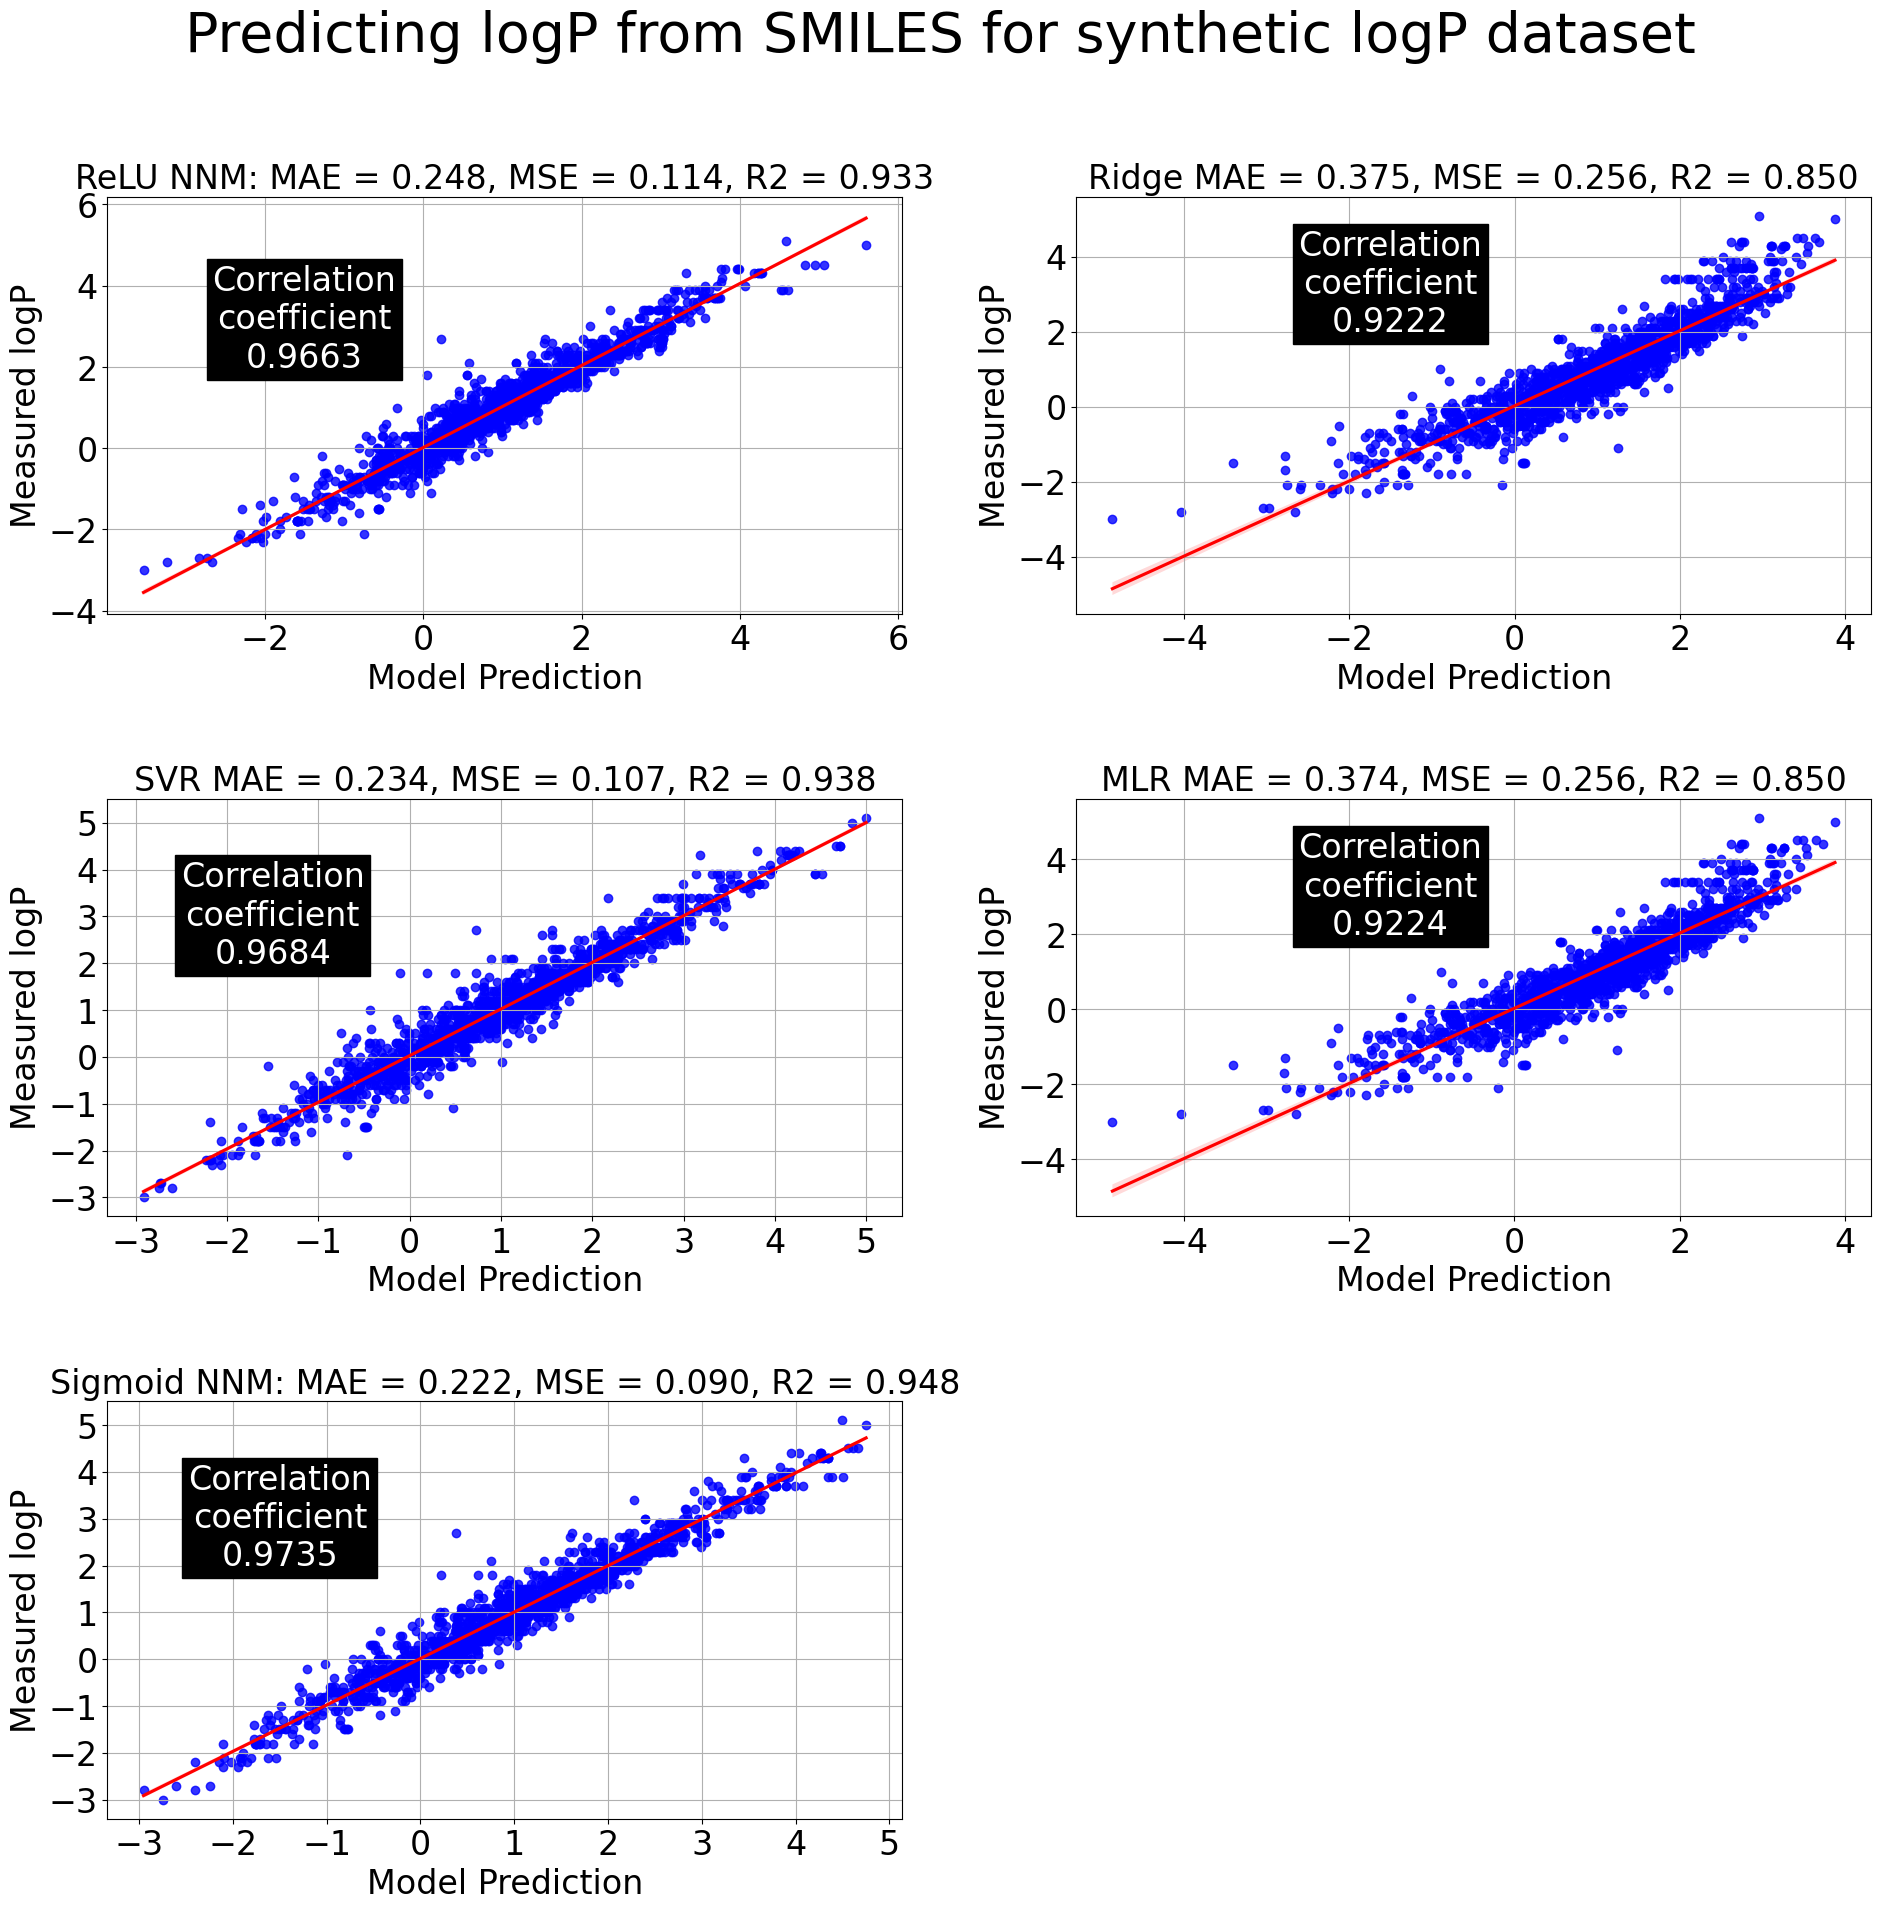

In [32]:
plot_both_evaluation(relu_NNM, ridge_pipe, svr_pipe, mlr_pipe, sigmoid_NNM, X_test, y_test)


# Import dataset with experimental logP values
### SMILES codes and experimental log P values of 759 purchased compounds (http://zinc.docking.org)

In [33]:
expt_df = pd.read_csv('logP_expt_dataset.csv', names=['smiles', 'logP'])
print(expt_df.shape)  
print(expt_df.head())

(753, 2)
                                       smiles  logP
0        Cc1cc2c(cc1C)NC(=O)C[C@H]2c3ccccc3OC  4.17
1       COc1ccc2c(c1)O[C@@](CC2=O)(C(F)(F)F)O  2.79
2  CC1(O[C@H]([C@H](O1)C(=O)N)C(=O)N)C(C)(C)C  1.60
3       CCOc1cc(cc(c1OCC)OCC)c2nnc(o2)c3ccco3  3.96
4         CN(C)c1ccc(cc1)C(=C)c2ccc(cc2)N(C)C  5.30


In [34]:
#dropping missing values
expt_df.dropna(axis=0, how='any', inplace=True)
expt_df.shape

(707, 2)

In [35]:
###confirming that there are no missing values
expt_df.isnull().sum()

smiles    0
logP      0
dtype: int64

In [36]:
expt_df['mol'] = expt_df['smiles'].apply(lambda x: Chem.MolFromSmiles(x)) 

expt_df.head(50)

[14:21:25] SMILES Parse Error: syntax error while parsing: Cc1cc(ccc1[N+](=O)[Or])C(=O)NCCc2c([nH]c3c2cccc3)C
[14:21:25] SMILES Parse Error: check for mistakes around position 21:
[14:21:25] Cc1cc(ccc1[N+](=O)[Or])C(=O)NCCc2c([nH]c3
[14:21:25] ~~~~~~~~~~~~~~~~~~~~^
[14:21:25] SMILES Parse Error: Failed parsing SMILES 'Cc1cc(ccc1[N+](=O)[Or])C(=O)NCCc2c([nH]c3c2cccc3)C' for input: 'Cc1cc(ccc1[N+](=O)[Or])C(=O)NCCc2c([nH]c3c2cccc3)C'
[14:21:25] SMILES Parse Error: syntax error while parsing: Cc1c(cccc1OCc2ccccc2)[N+](=O)[Or]
[14:21:25] SMILES Parse Error: check for mistakes around position 32:
[14:21:25] Cc2ccccc2)[N+](=O)[Or]
[14:21:25] ~~~~~~~~~~~~~~~~~~~~^
[14:21:25] SMILES Parse Error: Failed parsing SMILES 'Cc1c(cccc1OCc2ccccc2)[N+](=O)[Or]' for input: 'Cc1c(cccc1OCc2ccccc2)[N+](=O)[Or]'
[14:21:25] SMILES Parse Error: syntax error while parsing: CC1(OC(=O)C(=Cc2ccc(s2)[N+](=O)[Or])C(=O)O1)C
[14:21:25] SMILES Parse Error: check for mistakes around position 34:
[14:21:25] Cc2ccc(s2)[N

,smiles,logP,mol
0,Cc1cc2c(cc1C)NC(=O)C[C@H]2c3ccccc3OC,4.17,<rdkit.Chem.rdchem.Mol object at 0x14d167fad430>
1,COc1ccc2c(c1)O[C@@](CC2=O)(C(F)(F)F)O,2.79,<rdkit.Chem.rdchem.Mol object at 0x14d167faf0b0>
2,CC1(O[C@H]([C@H](O1)C(=O)N)C(=O)N)C(C)(C)C,1.60,<rdkit.Chem.rdchem.Mol object at 0x14d167fafc80>
3,CCOc1cc(cc(c1OCC)OCC)c2nnc(o2)c3ccco3,3.96,<rdkit.Chem.rdchem.Mol object at 0x14d167fabc10>
4,CN(C)c1ccc(cc1)C(=C)c2ccc(cc2)N(C)C,5.30,<rdkit.Chem.rdchem.Mol object at 0x14d167fabac0>
5,Cc1ccc(o1)[C@H](C#CC(c2ccccc2)(c3ccccc3)O)O,3.53,<rdkit.Chem.rdchem.Mol object at 0x14d167fab970>
6,CC(C)(C)c1cc(n[nH]1)Cc2ccccc2,4.35,<rdkit.Chem.rdchem.Mol object at 0x14d167fab270>
7,C[C@H]1C[C@@H](CC(C1)(C)C)NC(=S)NCc2csc3c2cccc3,6.21,<rdkit.Chem.rdchem.Mol object at 0x14d167fa8f20>
8,CCNc1nc(nc(n1)Oc2ccc(nn2)OCC)NC(C)C,3.14,<rdkit.Chem.rdchem.Mol object at 0x14d167fa8d60>
9,c1ccc2c(c1)OCCOCCOCCO2,1.81,<rdkit.Chem.rdchem.Mol object at 0x14d167fa8c10>


In [37]:
#dropping missing values
expt_df.dropna(axis=0, how='any', inplace=True)
print(expt_df.shape)

###confirming that there are no missing values
print(expt_df.isnull().sum())

(658, 3)
smiles    0
logP      0
mol       0
dtype: int64


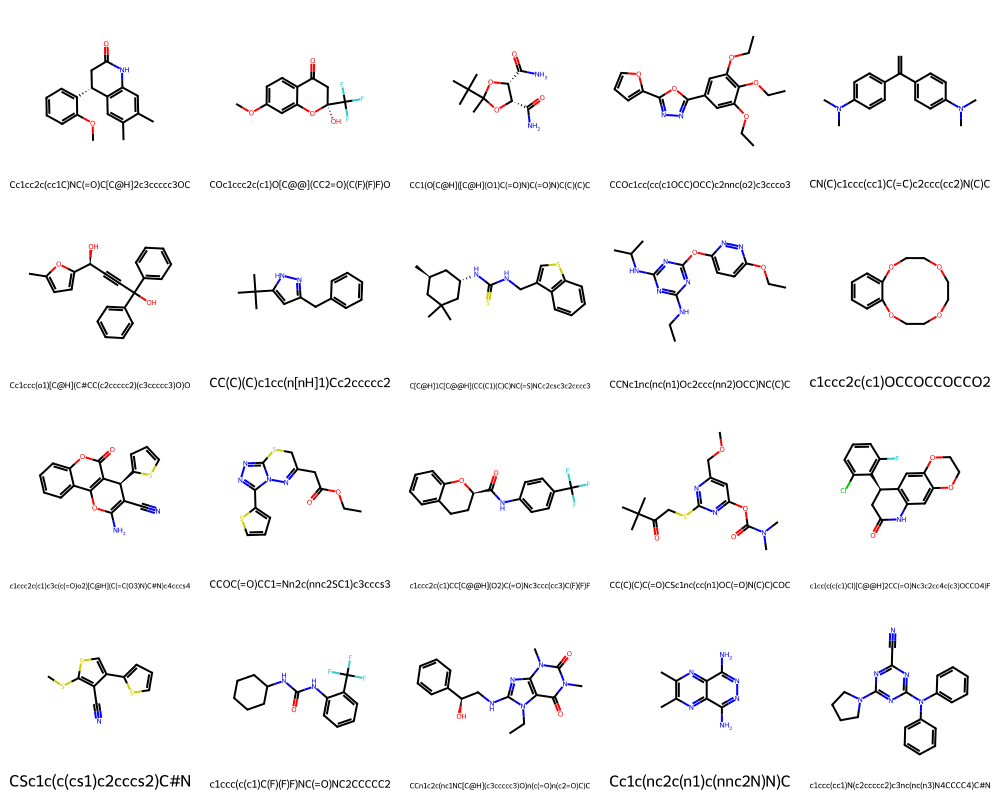

In [38]:
number_to_print = 20
mols = expt_df['mol'][:number_to_print]

#MolsToGridImage allows to show several molecules in a grid
Draw.MolsToGridImage(mols, molsPerRow=5, useSVG=True, legends=list(expt_df['smiles'][:number_to_print].values))

# Creating features for the model

In [39]:
# AddHs function adds H atoms to a MOL (as Hs in SMILES are usualy ignored)
expt_df['mol'] = expt_df['mol'].apply(lambda x: Chem.AddHs(x))

In [40]:
# GetNumAtoms() method returns a general nubmer of all atoms in a molecule
expt_df['num_of_atoms'] = expt_df['mol'].apply(lambda x: x.GetNumAtoms())

# GetNumHeavyAtoms() method returns a nubmer of all atoms in a molecule with molecular weight > 1
expt_df['num_of_heavy_atoms'] = expt_df['mol'].apply(lambda x: x.GetNumHeavyAtoms())

#Searching for patterns and use it for a list of most common atoms only
def number_of_atoms(atom_list, df):
    for i in atom_list:
        expt_df['num_of_{}_atoms'.format(i)] = expt_df['mol'].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmiles(i))))

number_of_atoms(['C', 'O', 'N', 'Cl', 'P', 'Br', 'F'], expt_df)

expt_df['tpsa'] = expt_df['mol'].apply(lambda x: Descriptors.TPSA(x)) #https://en.wikipedia.org/wiki/Polar_surface_area
expt_df['mol_w'] = expt_df['mol'].apply(lambda x: Descriptors.ExactMolWt(x)) # https://en.wikipedia.org/wiki/Molecular_mass
expt_df['num_valence_electrons'] = expt_df['mol'].apply(lambda x: Descriptors.NumValenceElectrons(x)) # https://en.wikipedia.org/wiki/Valence_electron
expt_df['num_heteroatoms'] = expt_df['mol'].apply(lambda x: Descriptors.NumHeteroatoms(x))

print(expt_df.shape)
expt_df.reset_index(drop=True, inplace=True)
print(expt_df.tail())

(658, 16)
                                                smiles  logP  \
653                  OCC#CC(c2ccc(F)cc2)(O)c1ccc(F)cc1  3.61   
654  CC/N=C\1/N(C(=O)/C(=C/c2cn(c3c2cccc3)CC(=O)Nc4...  5.80   
655  c1ccc2c(c1)nc(n2C[C@@H](CO)O)SCCSc3nc4ccccc4n3...  3.29   
656                              CCOC(=O)c1ccc(cc1)C#N  1.87   
657                 C=CCn(c2=O)c(SCc3ccccc3)nc1c2cccc1  5.11   

                                                  mol  num_of_atoms  \
653  <rdkit.Chem.rdchem.Mol object at 0x14d167b6aa50>            32   
654  <rdkit.Chem.rdchem.Mol object at 0x14d167b6aac0>            58   
655  <rdkit.Chem.rdchem.Mol object at 0x14d167b6ab30>            58   
656  <rdkit.Chem.rdchem.Mol object at 0x14d167b6aba0>            22   
657  <rdkit.Chem.rdchem.Mol object at 0x14d167b6ac10>            38   

     num_of_heavy_atoms  num_of_C_atoms  num_of_O_atoms  num_of_N_atoms  \
653                  20              16               2               0   
654                  32     

In [41]:
import requests

url = 'https://github.com/samoturk/mol2vec_notebooks/raw/master/Notebooks/model_300dim.pkl'
file_to_download = requests.get(url, allow_redirects=True)

open('model_300dim.pkl', 'wb').write(file_to_download.content)

26567327

In [42]:
from mol2vec.features import mol2alt_sentence, mol2sentence, MolSentence, DfVec, sentences2vec

In [43]:
#Loading pre-trained model via word2vec
from gensim.models import word2vec  # https://radimrehurek.com/gensim/index.html#install
w2vec_model = word2vec.Word2Vec.load('model_300dim.pkl') # Download from https://github.com/samoturk/mol2vec_notebooks/blob/master/Notebooks/model_300dim.pkl

In [45]:
from gensim.models import KeyedVectors
import numpy as np

def sentences2vec(sentences, model: KeyedVectors, unseen=None):
    keys = set(model.key_to_index.keys())  # Gensim 4 compatible
    vec = []
    for sentence in sentences:
        this_vec = []
        for word in sentence:  # or sentence.sentence if needed
            if word in keys:
                this_vec.append(model[word])
            elif unseen:
                this_vec.append(model[unseen])
        if this_vec:
            vec.append(np.sum(this_vec, axis=0))
        else:
            vec.append(np.zeros(model.vector_size))
    return vec

#Constructing sentences
expt_df['sentence'] = expt_df.apply(lambda x: MolSentence(mol2alt_sentence(x['mol'], 1)), axis=1)
expt_df['mol2vec'] = [DfVec(x) for x in sentences2vec(expt_df['sentence'], w2vec_model.wv, unseen='UNK')]


#Extracting embeddings to a numpy.array
#unseen='UNK' in sentence2vec() so that model is taught how to handle unknown substructures
#expt_df['mol2vec'] = [DfVec(x) for x in sentences2vec(expt_df['sentence'], w2vec_model, unseen='UNK')]

y = expt_df['logP'].values
X = np.array([x.vec for x in expt_df['mol2vec']])

[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerator
[14:21:56] DEPRECATION WARNING: please use MorganGenerat

In [46]:
X = pd.concat((pd.DataFrame(X), expt_df.drop(["mol2vec", "sentence", "smiles", "mol", "logP"], axis=1)), axis=1)
print(X.tail())

             0          1          2         3          4          5  \
653  -5.907644   7.218061 -10.314885  0.138781  -7.975831  -7.522517   
654  -9.523583  13.264157 -19.235048  2.355275 -10.269159 -20.154163   
655 -16.336416   8.531381 -19.561672  2.096289  -8.403242 -14.107118   
656  -1.605527   3.756545  -7.407247 -1.423647  -2.579208  -7.511415   
657 -10.717519   7.531511 -12.917501  1.052022  -6.413111  -9.623880   

             6         7          8          9  ...  num_of_O_atoms  \
653   6.117581 -3.444097  -7.492716 -23.604782  ...               2   
654  11.070551 -8.361683 -18.408190 -40.172409  ...               2   
655  14.221850 -3.765782 -16.532171 -44.347328  ...               4   
656   6.005766 -2.921795  -6.767901 -15.301554  ...               2   
657   9.007222 -3.321106 -10.460451 -28.206047  ...               1   

     num_of_N_atoms  num_of_Cl_atoms  num_of_P_atoms  num_of_Br_atoms  \
653               0                0               0               

In [47]:
#add a 1 behind to differentiate from synthetic logP dataset
X_train1, X_remain1, y_train1, y_remain1 = train_test_split(X, y, test_size=.2, random_state=816)
X_val1, X_test1, y_val1, y_test1 = train_test_split(X_remain1, y_remain1, test_size=.5, random_state=817)

In [48]:
X_train1.columns = X_train1.columns.astype(str)
X_test1.columns = X_test1.columns.astype(str)

# Fitting pipeline onto experimental dataset

In [49]:
# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train1, y_train1)
  
# Compare accuracies
for idx, val in enumerate(pipelines):
    print('%s pipeline test r2 score: %.3f' % (pipe_dict[idx], val.score(X_test1, y_test1)))
    
# Identify the most accurate model on test data
best_acc = 0.0
best_reg = 0
best_pipe = ''
for idx, val in enumerate(pipelines):
    if val.score(X_test1, y_test1) > best_acc:
        best_acc = val.score(X_test1, y_test1)
        best_pipe = val
        best_reg = idx
print('Model with best r2 score: %s' % pipe_dict[best_reg])

# Save pipeline to file
joblib.dump(best_pipe, 'best_pipeline.pkl', compress=1)
# print('Saved %s pipeline to file' % pipe_dict[best_reg])

Ridge Regression pipeline test r2 score: 0.587
Support Vector Regression pipeline test r2 score: 0.582
Multiple Linear Regression pipeline test r2 score: 0.517
Model with best r2 score: Ridge Regression


['best_pipeline.pkl']

# Neural network models for experimental dataset

### Neural network model (activation function = ReLU)

In [50]:
inputs = tf.keras.layers.Input(shape=(X_train1.shape[1],), name="mol2vec")

dense1_relu = tf.keras.layers.Dense(128, activation="relu")(inputs)
drop1_relu  = tf.keras.layers.Dropout(0.3)(dense1_relu)
prediction_relu = tf.keras.layers.Dense(1, activation="linear", name="logP_value")(drop1_relu)

relu_NNM = tf.keras.models.Model(inputs=[inputs], outputs=[prediction_relu], name="logP_Model")

relu_NNM.summary()


Model: "logP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mol2vec (InputLayer)            │ (None, 113)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logP_value (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

### Neural network model (activation function = sigmoid)

In [51]:
dense1_sigmoid = tf.keras.layers.Dense(128, activation="sigmoid")(inputs)
drop1_sigmoid  = tf.keras.layers.Dropout(0.3)(dense1_sigmoid)
prediction_sigmoid = tf.keras.layers.Dense(1, activation="linear", name="logP_value")(drop1_sigmoid)

sigmoid_NNM = tf.keras.models.Model(inputs=[inputs], outputs=[prediction_sigmoid], name="logP_Model")

sigmoid_NNM.summary()

Model: "logP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mol2vec (InputLayer)            │ (None, 113)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logP_value (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

### Fitting neural network models onto experimental dataset 

In [52]:
relu_NNM.compile(
    loss="mse",
    metrics=["mse", "mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4)  # Learning rate must be low
)

sigmoid_NNM.compile(
    loss="mse",
    metrics=["mse", "mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4)
)


In [53]:
%load_ext tensorboard

stopping = tf.keras.callbacks.EarlyStopping(patience=30, verbose=1, restore_best_weights=True)

tensorboard = tf.keras.callbacks.TensorBoard(log_dir='logs')

checkpoint_dir = "logP_model.keras"  # or use .h5 if you prefer HDF5
checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_dir, monitor='val_loss', verbose=1, save_best_only=True)


# %tensorboard --logdir logs


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [54]:
relu_NNM.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=1000, callbacks=[stopping, tensorboard, checkpoint])

Epoch 1/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


 1/17 ━━━━━━━━━━━━━━━━━━━━ 14s 915ms/step - loss: 1285.2280 - mae: 27.3230 - mse: 1285.2280
Epoch 1: val_loss improved from inf to 30.23024, saving model to logP_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1152.2310 - mae: 26.7135 - mse: 1152.2310 - val_loss: 30.2302 - val_mae: 4.6642 - val_mse: 30.2302
Epoch 2/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 718.8879 - mae: 21.8823 - mse: 718.8879

/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)



Epoch 2: val_loss did not improve from 30.23024
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 952.2789 - mae: 24.1252 - mse: 952.2789 - val_loss: 34.3045 - val_mae: 5.1426 - val_mse: 34.3045
Epoch 3/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 759.5136 - mae: 21.6557 - mse: 759.5136
Epoch 3: val_loss improved from 30.23024 to 19.73983, saving model to logP_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 763.6055 - mae: 21.4824 - mse: 763.6055 - val_loss: 19.7398 - val_mae: 3.7603 - val_mse: 19.7398
Epoch 4/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 675.0626 - mae: 21.8551 - mse: 675.0626
Epoch 4: val_loss improved from 19.73983 to 7.38534, saving model to logP_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 600.6815 - mae: 19.6722 - mse: 600.6815 - val_loss: 7.3853 - val_mae: 2.2535 - val_mse: 7.3853
Epoch 5/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 455.4058 - mae: 14.8522 - mse: 455.4058
Epoch 5: val_loss improved from 7.38534 to 5.

In [55]:
sigmoid_NNM.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=1000, callbacks=[stopping, tensorboard, checkpoint])

Epoch 1/1000


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)


 1/17 ━━━━━━━━━━━━━━━━━━━━ 8s 561ms/step - loss: 15.5463 - mae: 3.6725 - mse: 15.5463
Epoch 1: val_loss did not improve from 0.49677
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 11.1283 - mae: 3.0035 - mse: 11.1283 - val_loss: 4.5282 - val_mae: 1.8757 - val_mse: 4.5282
Epoch 2/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 4.5818 - mae: 1.8950 - mse: 4.5818

/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)



Epoch 2: val_loss did not improve from 0.49677
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6214 - mae: 1.8180 - mse: 4.6214 - val_loss: 2.2384 - val_mae: 1.1914 - val_mse: 2.2384
Epoch 3/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.5932 - mae: 1.5518 - mse: 3.5932
Epoch 3: val_loss did not improve from 0.49677
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2693 - mae: 1.4988 - mse: 3.2693 - val_loss: 1.5821 - val_mae: 1.0042 - val_mse: 1.5821
Epoch 4/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.0694 - mae: 1.1596 - mse: 2.0694
Epoch 4: val_loss did not improve from 0.49677
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3846 - mae: 1.2555 - mse: 2.3846 - val_loss: 1.2124 - val_mae: 0.8923 - val_mse: 1.2124
Epoch 5/1000
 1/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.4241 - mae: 0.9515 - mse: 1.4241
Epoch 5: val_loss did not improve from 0.49677
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9438 - mae: 1.1170 - mse: 1.9438 - val_loss: 1.0896 - val_mae: 

# Plots for experimental logP dataset

In [56]:
def plot_both_evaluation(relu_NNM, ridge_pipe, svr_pipe, mlr_pipe, sigmoid_NNM, X_test1, y_test1):
    """
    Scatter plot between target and prediction logP values for both models
    """
    
    prediction_relu_NNM = relu_NNM.predict(X_test1)
    mae_relu_NNM = mean_absolute_error(y_test1, prediction_relu_NNM)
    mse_relu_NNM = mean_squared_error(y_test1, prediction_relu_NNM)
    r2_relu_NNM = r2_score(y_test1, prediction_relu_NNM)
    
    prediction_ridge = ridge_pipe.predict(X_test1)
    mae_ridge = mean_absolute_error(y_test1, prediction_ridge)
    mse_ridge = mean_squared_error(y_test1, prediction_ridge)
    r2_ridge = r2_score(y_test1, prediction_ridge)
    
    prediction_svr = svr_pipe.predict(X_test1)
    mae_svr = mean_absolute_error(y_test1, prediction_svr)
    mse_svr = mean_squared_error(y_test1, prediction_svr)
    r2_svr = r2_score(y_test1, prediction_svr)
    
    prediction_mlr = mlr_pipe.predict(X_test1)
    mae_mlr = mean_absolute_error(y_test1, prediction_mlr)
    mse_mlr = mean_squared_error(y_test1, prediction_mlr)
    r2_mlr = r2_score(y_test1, prediction_mlr)
    
    prediction_sigmoid_NNM = sigmoid_NNM.predict(X_test1)
    mae_sigmoid_NNM = mean_absolute_error(y_test1, prediction_sigmoid_NNM)
    mse_sigmoid_NNM = mean_squared_error(y_test1, prediction_sigmoid_NNM)
    r2_sigmoid_NNM = r2_score(y_test1, prediction_sigmoid_NNM)


###Neural Network (activation function = ReLU)###
    plt.figure(figsize=(20,20))
    plt.subplot(3,2,1);
    sns.regplot(x=prediction_relu_NNM, y=y_test1, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for experimental logP dataset', fontsize=40);
    plt.title(f'ReLU NNM: MAE = {mae_relu_NNM:.3f}, MSE = {mse_relu_NNM:.3f}, R2 = {r2_relu_NNM:.3f}', fontsize=24);
    cc = np.corrcoef(y_test1, np.squeeze(prediction_relu_NNM))
    plt.text(2, 4.5, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);

###Ridge###
    plt.subplot(3,2,2);
    sns.regplot(x=prediction_ridge, y=y_test1, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for experimental logP dataset', fontsize=40);
    plt.title(f'Ridge MAE = {mae_ridge:.3f}, MSE = {mse_ridge:.3f}, R2 = {r2_ridge:.3f}', fontsize=24);
    cc = np.corrcoef(y_test1, np.squeeze(prediction_ridge))
    plt.text(2, 4.5, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);

###svr###
    plt.subplot(3,2,3);
    sns.regplot(x=prediction_svr, y=y_test1, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for experimental logP dataset', fontsize=40);
    plt.title(f'SVR MAE = {mae_svr:.3f}, MSE = {mse_svr:.3f}, R2 = {r2_svr:.3f}', fontsize=24);
    cc = np.corrcoef(y_test1, np.squeeze(prediction_svr))
    plt.text(2, 4.5, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);
    
###mlr###
    plt.subplot(3,2,4);
    sns.regplot(x=prediction_mlr, y=y_test1, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for experimental logP dataset', fontsize=40);
    plt.title(f'MLR MAE = {mae_mlr:.3f}, MSE = {mse_mlr:.3f}, R2 = {r2_mlr:.3f}', fontsize=24);
    cc = np.corrcoef(y_test1, np.squeeze(prediction_mlr))
    plt.text(2, 4.5, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);
    
###Neural Network (activation function = sigmoid)###
    plt.subplot(3,2,5);
    sns.regplot(x=prediction_sigmoid_NNM, y=y_test1, scatter_kws={"color": "blue"}, line_kws={"color": "red"});
    plt.xlabel('Model Prediction', fontsize=24);
    plt.ylabel('Measured logP', fontsize=24);
    plt.xticks(fontsize=24);
    plt.yticks(fontsize=24);
    plt.suptitle('Predicting logP from SMILES for experimental logP dataset', fontsize=40);
    plt.title(f'Sigmoid NNM: MAE = {mae_sigmoid_NNM:.3f}, MSE = {mse_sigmoid_NNM:.3f}, R2 = {r2_sigmoid_NNM:.3f}', fontsize=24);
    cc = np.corrcoef(y_test1, np.squeeze(prediction_sigmoid_NNM))
    plt.text(3, 4.5, f"Correlation\ncoefficient\n{cc[0][1]:.4f}", fontsize=24, 
             horizontalalignment="center", backgroundcolor="black", color="white")
    plt.grid(True);
    plt.tight_layout(pad=5.0)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/stepWARNING:tensorflow:5 out of the last 52 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x14d1b4ce9af0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(32, 113))
  warnings.warn(msg)
/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(None, 113))
  warnings.warn(msg)
/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(32, 113))
  warnings.warn(msg)
/home/dnehra/.conda/envs/tf_env/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mol2vec']
Received: inputs=Tensor(shape=(N

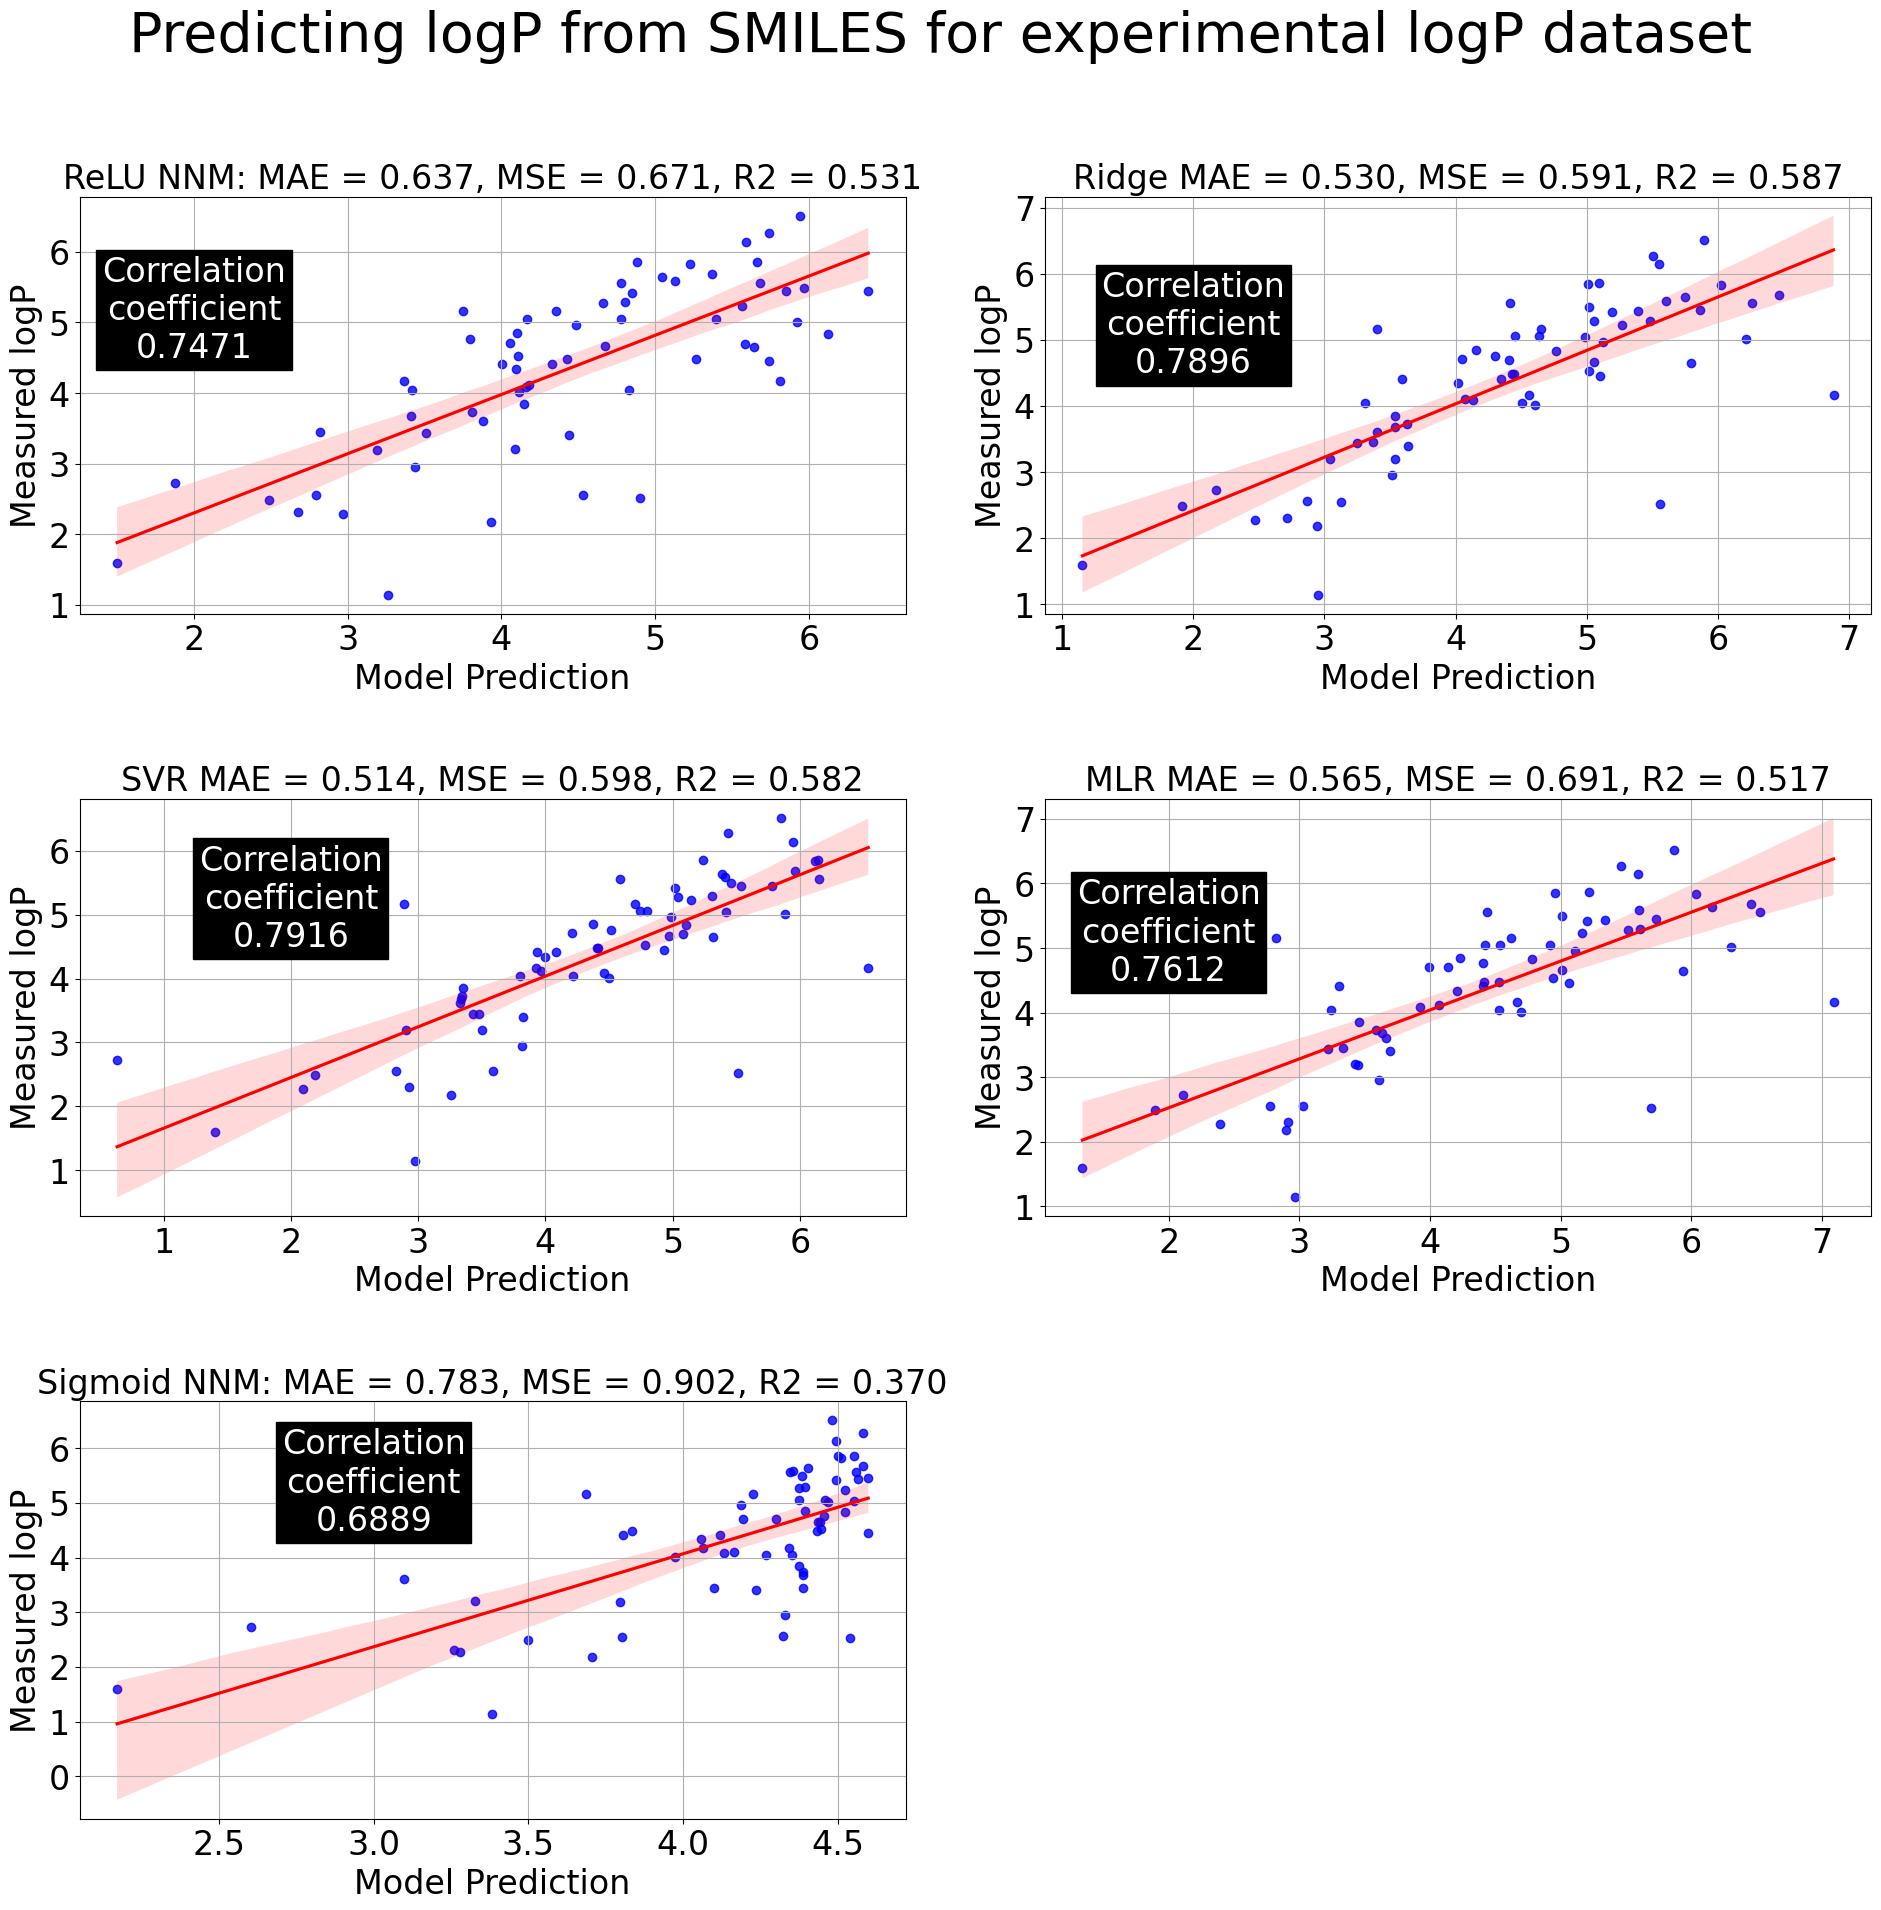

In [57]:
plot_both_evaluation(relu_NNM, ridge_pipe, svr_pipe, mlr_pipe, sigmoid_NNM, X_test1, y_test1)


In [58]:
import pandas as pd

# Replace with your actual CSV filename
your_data = pd.read_csv('new.csv')  # Ensure your file has a 'SMILES' column
print(your_data.head())


                                              smiles  \
0  O=C(N1CCCC1)[C@H](CCC2)CN2C(N=C3N4)=CC=C3N=C4C...   
1  O=C(N1CCCC1)[C@H](CCC2)CN2C(N=C3N4)=CC=C3N=C4C...   
2  O=C(N1CCCC1)[C@H](CCC2)CN2C(N=C3N4)=CC=C3N=C4C...   
3  O=C(N1CCCC1)[C@H](CCC2)CN2C(N=C3N4)=CC=C3N=C4C...   
4  O=C(N1CCCC1)[C@H](CCC2)CN2C(N=C3N4)=CC=C3N=C4C...   

                                                mol  \
0  <rdkit.Chem.rdchem.Mol object at 0x1489db416f20>   
1  <rdkit.Chem.rdchem.Mol object at 0x1489db416eb0>   
2  <rdkit.Chem.rdchem.Mol object at 0x1489db416e40>   
3  <rdkit.Chem.rdchem.Mol object at 0x1489db416dd0>   
4  <rdkit.Chem.rdchem.Mol object at 0x1489db416d60>   

                     sentence  logP_pred_using_ml.csv  
0  MolSentence with 120 words               11.866805  
1  MolSentence with 120 words               11.284408  
2  MolSentence with 122 words               10.961071  
3  MolSentence with 116 words               11.721786  
4  MolSentence with 114 words               10.21173

In [59]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)


In [60]:
# Generate fingerprints for each SMILES in your dataset
fps = [smiles_to_fingerprint(smiles) for smiles in your_data['smiles']]

# Filter out None values (invalid SMILES)
valid_fps = [fp for fp in fps if fp is not None]
valid_indices = [i for i, fp in enumerate(fps) if fp is not None]

# Convert to NumPy array
X_pred = np.array([np.array(fp) for fp in valid_fps])


[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerator
[14:24:07] DEPRECATION WARNING: please use MorganGenerat

In [61]:
print(w2vec_model.vector_size)  # Should return 113 if that's what the model expects


100


In [63]:
from gensim.models import KeyedVectors

def sentences2vec(sentences, model: KeyedVectors, unseen=None):
    keys = set(model.key_to_index.keys())  # Gensim 4+
    vec = []
    for sentence in sentences:
        this_vec = []
        for word in sentence.words:
            if word in keys:
                this_vec.append(model[word])
            elif unseen is not None:
                this_vec.append(model[unseen])
        if this_vec:
            vec.append(np.sum(this_vec, axis=0))
        else:
            vec.append(np.zeros(model.vector_size,))
    return vec

import numpy as np

def sentences2vec(sentences, model, unseen=None):
    keys = set(model.key_to_index.keys())  # Gensim 4.x compatible
    vec = []
    for i, sentence in enumerate(sentences):
        this_vec = []
        unknown_word_count = 0
        for word in sentence:  # ✅ DIRECTLY iterate (don't use .words)
            if word in keys:
                this_vec.append(model[word])
            elif unseen is not None and unseen in keys:
                this_vec.append(model[unseen])
                unknown_word_count += 1
            else:
                unknown_word_count += 1
        if unknown_word_count == len(sentence):
            print(f"❌ All words unknown for SMILES: {your_data.iloc[i]['smiles']}")
        if this_vec:
            vec.append(np.sum(this_vec, axis=0))
        else:
            vec.append(np.zeros(model.vector_size,))
    return vec


import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from mol2vec.features import mol2alt_sentence, MolSentence, DfVec
import pandas as pd

your_data = pd.read_csv("oct.csv")

# Step 1: Convert SMILES to Mol objects
your_data['mol'] = your_data['smiles'].apply(Chem.MolFromSmiles)
your_data = your_data[your_data['mol'].notnull()].copy()

# Step 2: Generate mol2vec sentences
your_data['sentence'] = your_data['mol'].apply(lambda mol: MolSentence(mol2alt_sentence(mol, radius=1)))
your_data = your_data.reset_index(drop=True)  # ✅ Ensure index aligns with sentence list
raw_vecs = sentences2vec(your_data['sentence'], w2vec_model.wv, unseen='UNK')

mol2vec_vecs = [DfVec(v) for v in raw_vecs]
X_mol2vec = np.array([v.vec for v in mol2vec_vecs])  # shape (n, 100)

# Step 3: Generate RDKit descriptors (same as training)
def compute_rdkit_features(mol):
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.NumValenceElectrons(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.NumAliphaticRings(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.MolMR(mol)
    ]

rdkit_features = your_data['mol'].apply(compute_rdkit_features)
X_rdkit = np.array(rdkit_features.tolist())  # shape (n, 13)

# Step 4: Concatenate both sets of features
X_pred = np.concatenate([X_mol2vec, X_rdkit], axis=1)  # shape (n, 113)

# Step 5: Predict using the trained model
predicted_logp = relu_NNM.predict(X_pred)
your_data['logP_pred_using_ml.csv'] = predicted_logp.flatten()

# Step 6: Export
your_data.to_csv("oct.csv", index=False)
your_data.to_csv("logP_pred_using_ml.csv", index=False)
print("✅ Prediction done. Results saved to 'logP_pred_using_ml.csv'")


[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerator
[14:26:16] DEPRECATION WARNING: please use MorganGenerat

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
✅ Prediction done. Results saved to 'logP_pred_using_ml.csv'


In [64]:
from gensim.models import KeyedVectors

def sentences2vec(sentences, model: KeyedVectors, unseen=None):
    keys = set(model.key_to_index.keys())  # Gensim 4+
    vec = []
    for sentence in sentences:
        this_vec = []
        for word in sentence.words:
            if word in keys:
                this_vec.append(model[word])
            elif unseen is not None:
                this_vec.append(model[unseen])
        if this_vec:
            vec.append(np.sum(this_vec, axis=0))
        else:
            vec.append(np.zeros(model.vector_size,))
    return vec
import numpy as np

def sentences2vec(sentences, model, unseen=None):
    keys = set(model.key_to_index.keys())  # Gensim 4.x compatible
    vec = []
    for sentence in sentences:
        this_vec = []
        for word in sentence:  # ✅ DIRECTLY iterate (don't use .words)
            if word in keys:
                this_vec.append(model[word])
            elif unseen is not None and unseen in keys:
                this_vec.append(model[unseen])
        if this_vec:
            vec.append(np.sum(this_vec, axis=0))
        else:
            vec.append(np.zeros(model.vector_size,))
    return vec


import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from mol2vec.features import mol2alt_sentence, MolSentence, DfVec
import pandas as pd
your_data = pd.read_csv("oct.csv")
# Step 1: Convert SMILES to Mol objects
your_data['mol'] = your_data['smiles'].apply(Chem.MolFromSmiles)
your_data = your_data[your_data['mol'].notnull()].copy()

# Step 2: Generate mol2vec sentences
your_data['sentence'] = your_data['mol'].apply(lambda mol: MolSentence(mol2alt_sentence(mol, radius=1)))
raw_vecs = sentences2vec(your_data['sentence'], w2vec_model.wv, unseen='UNK')



mol2vec_vecs = [DfVec(v) for v in raw_vecs]
X_mol2vec = np.array([v.vec for v in mol2vec_vecs])  # shape (n, 100)

# Step 3: Generate RDKit descriptors (same as training)
def compute_rdkit_features(mol):
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.NumValenceElectrons(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.NumAliphaticRings(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.MolMR(mol)
    ]

rdkit_features = your_data['mol'].apply(compute_rdkit_features)
X_rdkit = np.array(rdkit_features.tolist())  # shape (n, 13)

# Step 4: Concatenate both sets of features
X_pred = np.concatenate([X_mol2vec, X_rdkit], axis=1)  # shape (n, 113)

# Step 5: Predict using the trained model
predicted_logp = relu_NNM.predict(X_pred)
your_data['logP_pred_using_ml.csv'] = predicted_logp.flatten()

# Step 6: Export
your_data.to_csv("oct.csv", index=False)
your_data.to_csv("logP_pred_using_ml.csv", index=False)
print("✅ Prediction done. Results saved to 'logP_pred_using_ml.csv'")


[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerator
[14:26:44] DEPRECATION WARNING: please use MorganGenerat

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
✅ Prediction done. Results saved to 'logP_pred_using_ml.csv'


In [65]:
import os
os.listdir()
# Save explicitly to your home directory or a known location
output_path = os.path.expanduser("~/logP_pred_using_ml.csv")
your_data.to_csv(output_path, index=False)

print(f"✅ File saved to: {output_path}")


✅ File saved to: /home/dnehra/logP_pred_using_ml.csv


In [66]:
import numpy as np
import pandas as pd
from rdkit import Chem
from mol2vec.features import mol2alt_sentence, MolSentence, DfVec, sentences2vec

# --- Step 1: Convert SMILES to RDKit Mol ---
your_data['mol'] = your_data['smiles'].apply(Chem.MolFromSmiles)

# Drop invalid molecules
your_data = your_data[your_data['mol'].notnull()].copy()

# --- Step 2: Create mol2vec sentences ---
your_data['sentence'] = your_data['mol'].apply(lambda mol: MolSentence(mol2alt_sentence(mol, radius=1)))

# Explicitly wrap with DfVec
raw_vecs = sentences2vec(your_data['sentence'], w2vec_model, unseen='UNK')
mol2vec_vecs = [DfVec(v) for v in raw_vecs]

# Now extract .vec safely
X_pred = np.array([vec.vec for vec in mol2vec_vecs])


# --- Step 5: Predict logP using your trained model ---
predicted_logp = relu_NNM.predict(X_pred)

# --- Step 6: Add predictions to DataFrame ---
your_data['Predicted1_LogP'] = predicted_logp.flatten()

# --- (Optional) Step 7: Export to CSV ---
your_data.to_csv("data.csv", index=False)

print("✅ Done! Predictions saved to 'predicted_logP_results.csv'")




[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerator
[14:28:19] DEPRECATION WARNING: please use MorganGenerat

AttributeError: The vocab attribute was removed from KeyedVector in Gensim 4.0.0.
Use KeyedVector's .key_to_index dict, .index_to_key list, and methods .get_vecattr(key, attr) and .set_vecattr(key, attr, new_val) instead.
See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4